In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2
mne.set_log_level('ERROR')
tl.get_backend()

'numpy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5

fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 26)

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings

bttda = BTTDA(
    n_blocks=8,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-20,
        init ='svd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lobpcg',
        taper=False,
        extra_train_info=False,
        verbose=False,
       
    ),
    gs_params=dict(n_jobs=-1, cv=StratifiedKFold(n_splits=10)),
    verbose=True,
    extra_train_info=True,
)
%env PYTHONWARNINGS=ignore
bttda.fit(X,y)

env: PYTHONWARNINGS=ignore
Fitting block 1/8...


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflo

(4200, 64)
0.8448734693877551


/home/arne/hoda-bci/src/hoda/backend.py:74: UserWarning: The problem size 8 minus the constraints size 0 is too small relative to the block size 8. Using a dense eigensolver instead of LOBPCG iterations.No output of the history of the iterations.
  return scipy.sparse.linalg.lobpcg(*args, **kwargs)
/home/arne/hoda-bci/src/hoda/backend.py:74: UserWarning: The problem size 26 minus the constraints size 0 is too small relative to the block size 8. Using a dense eigensolver instead of LOBPCG iterations.No output of the history of the iterations.
  return scipy.sparse.linalg.lobpcg(*args, **kwargs)


Fitting block 2/8...
(4200, 65)
0.8567673469387757
Fitting block 3/8...
(4200, 66)
0.8572163265306123
Fitting block 4/8...
(4200, 67)
0.8589755102040817
Fitting block 5/8...


...

Fitting block 8/8...


/home/arne/hoda-bci/src/hoda/backend.py:74: UserWarning: The problem size 8 minus the constraints size 0 is too small relative to the block size 8. Using a dense eigensolver instead of LOBPCG iterations.No output of the history of the iterations.
  return scipy.sparse.linalg.lobpcg(*args, **kwargs)
/home/arne/hoda-bci/src/hoda/backend.py:74: UserWarning: The problem size 26 minus the constraints size 0 is too small relative to the block size 8. Using a dense eigensolver instead of LOBPCG iterations.No output of the history of the iterations.
  return scipy.sparse.linalg.lobpcg(*args, **kwargs)


(4200, 140)
0.8357142857142856


/home/arne/hoda-bci/src/hoda/backend.py:74: UserWarning: The problem size 8 minus the constraints size 0 is too small relative to the block size 8. Using a dense eigensolver instead of LOBPCG iterations.No output of the history of the iterations.
  return scipy.sparse.linalg.lobpcg(*args, **kwargs)
/home/arne/hoda-bci/src/hoda/backend.py:74: UserWarning: The problem size 26 minus the constraints size 0 is too small relative to the block size 8. Using a dense eigensolver instead of LOBPCG iterations.No output of the history of the iterations.
  return scipy.sparse.linalg.lobpcg(*args, **kwargs)


BTTDA(extra_train_info=True,
      gs_params={'cv': StratifiedKFold(n_splits=10, random_state=None, shuffle=False),
                 'n_jobs': -1, 'refit': True, 'scoring': 'roc_auc'},
      hoda_params={'extra_train_info': False, 'init': 'svd', 'max_iter': 64,
                   'obj': 'rt', 'rank': None, 'shrinkage': 'lw',
                   'solver': 'lobpcg', 'taper': False, 'toeplitz': (1,),
                   'tol': 1e-20, 'verbose': False},
      verbose=True)

In [16]:
bttda.train_info_

,score,rank,mse
block,,,
1,0.844873,"(8, 8)",5.699153e-11
2,0.856767,"(1, 1)",5.182714e-11
3,0.857216,"(1, 1)",5.188508e-11
4,0.858976,"(1, 1)",5.184221e-11
5,0.852624,"(1, 1)",5.194059e-11
6,0.853518,"(2, 2)",5.299309e-11
7,0.846776,"(2, 2)",5.377907e-11
8,0.835714,"(8, 8)",5.758033e-11


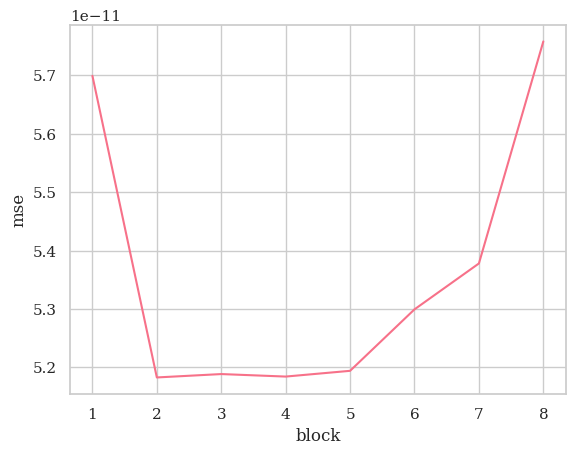

<Axes: xlabel='block', ylabel='score'>

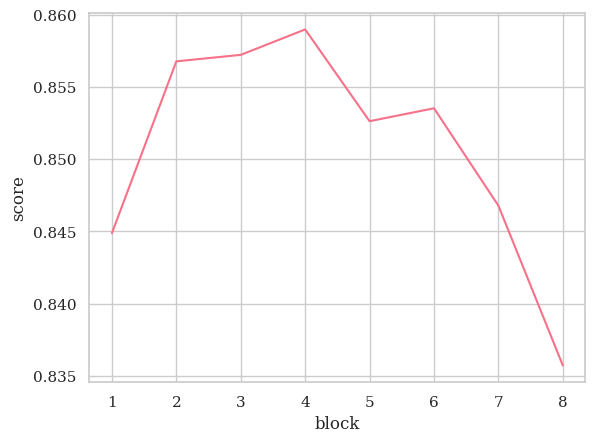

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

n_samples = X.shape[0]
sns.lineplot(data=bttda.train_info_, x='block', y='mse')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='score')



In [8]:
Xt = bttda.transform(X)

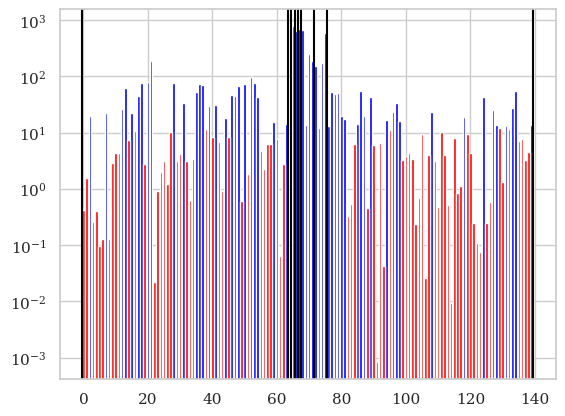

In [9]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b in bttda.blocks_:
    n_params+=math.prod(b.ml_rank_)
    plt.axvline(n_params-.5, color='black')


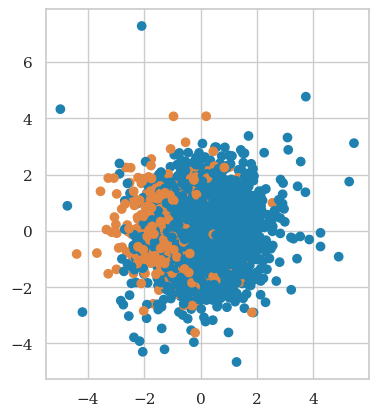

In [10]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [11]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

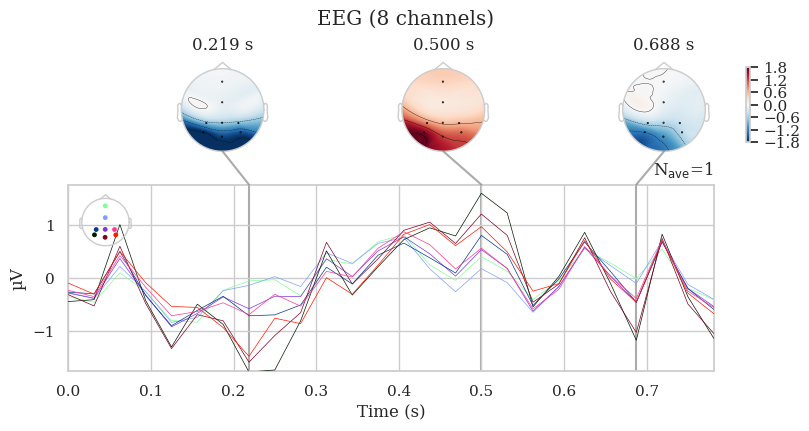

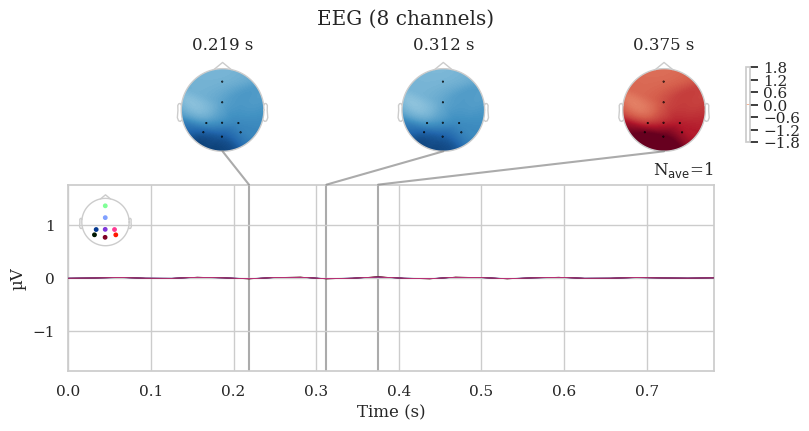

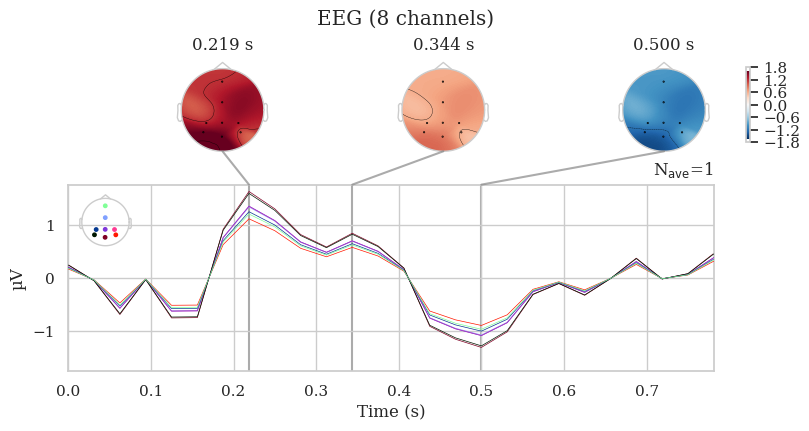

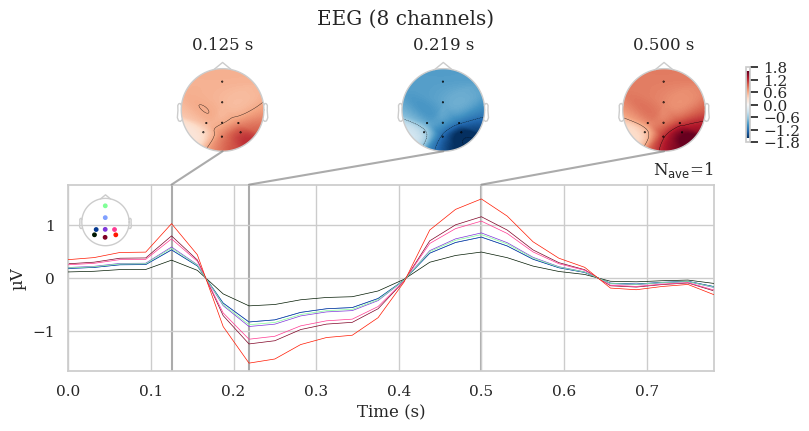

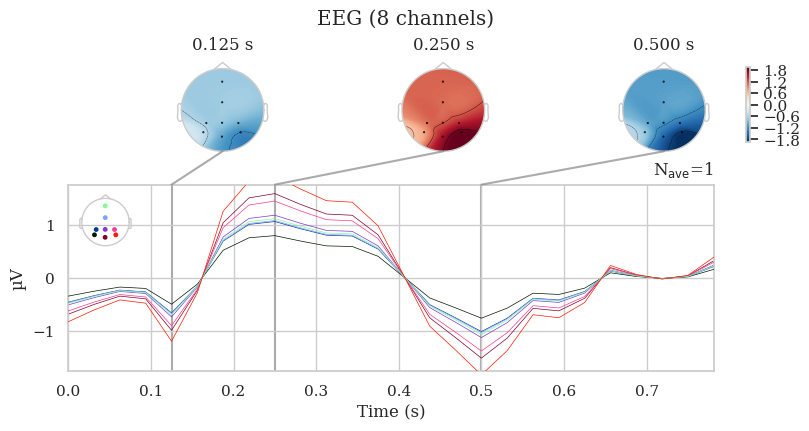

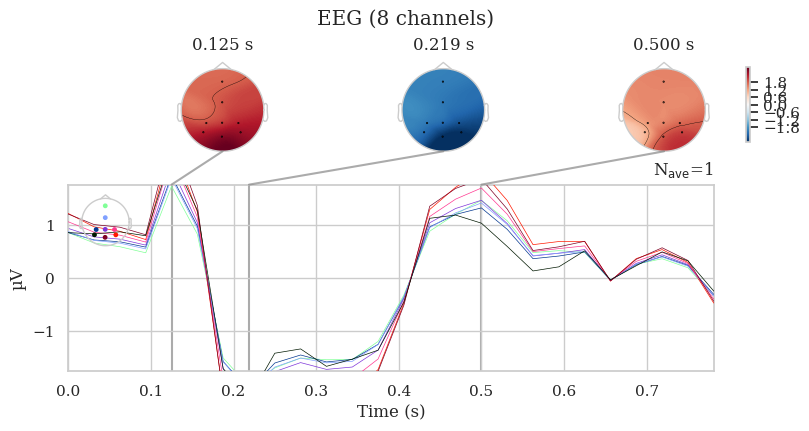

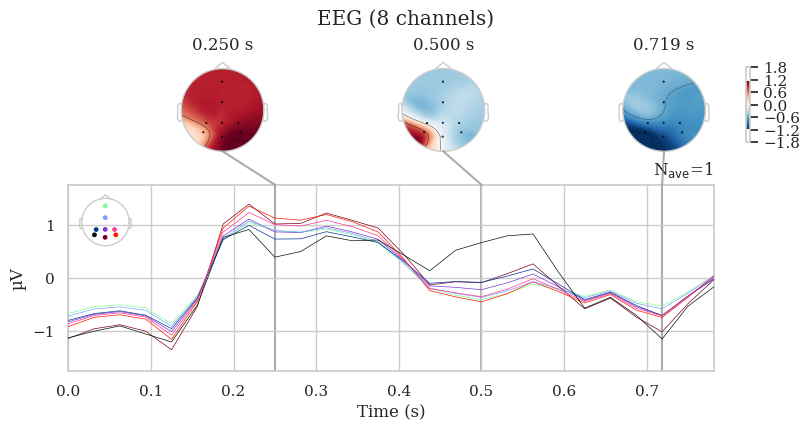

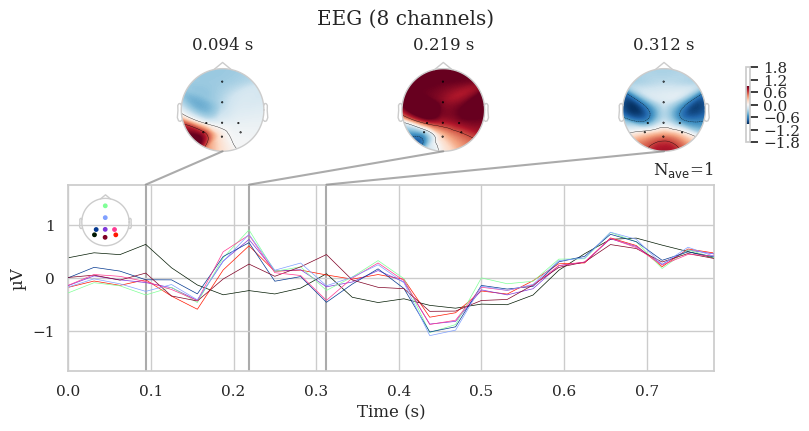

In [12]:
from mne import EvokedArray
for b in bttda.blocks_:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [13]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

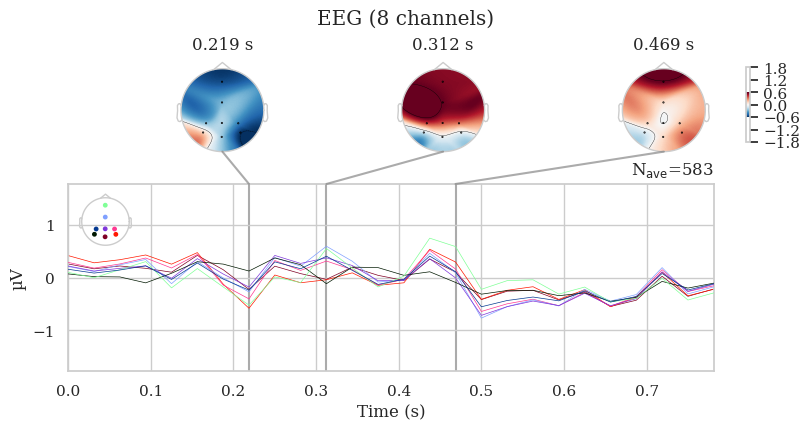

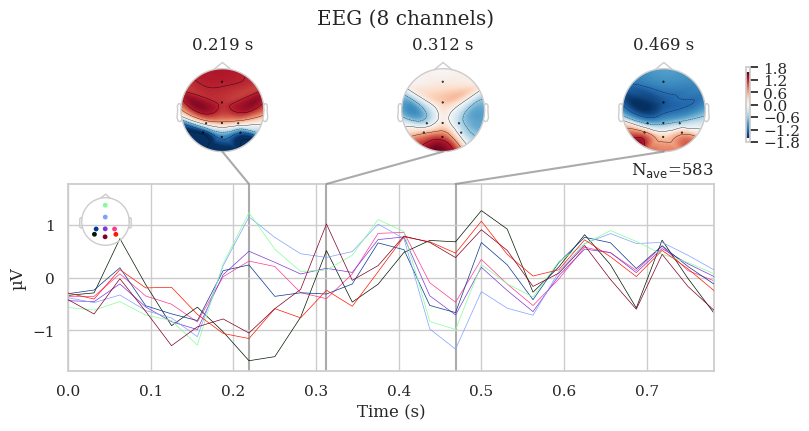

In [14]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


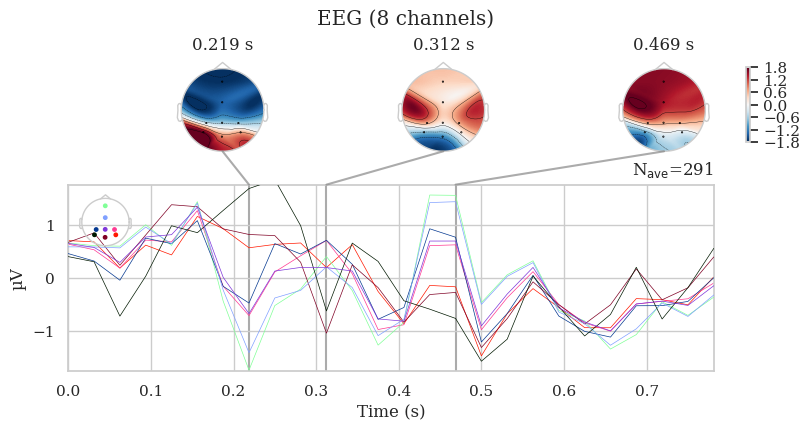

In [15]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)